# Analysis for case $b=1$ and $\sigma = x+1$

## Liberaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os


## Import helper functions 

In [2]:
from sources.simulation import numerical_solution, euler_maruyama
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

## Parameters

In [3]:
#this is to make sure that lambda functions are deleted before defining new one
for var_name in ['b', 'sigma']:
    if var_name in locals():
        del locals()[var_name]

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions
b = lambda x: constant_drift(x, value=1)
sigma = lambda x: linear_diffusion(x, slope=1, intercept=1) 

#these are used to load generated solutions
problem_path = "./data/b-1_s-xp1"
boundary_types = ["reflection", "rejection", "theta-0.5", "half-step"]
dt_list = [0.16, 0.04, 0.01, 0.0025]

## General solution

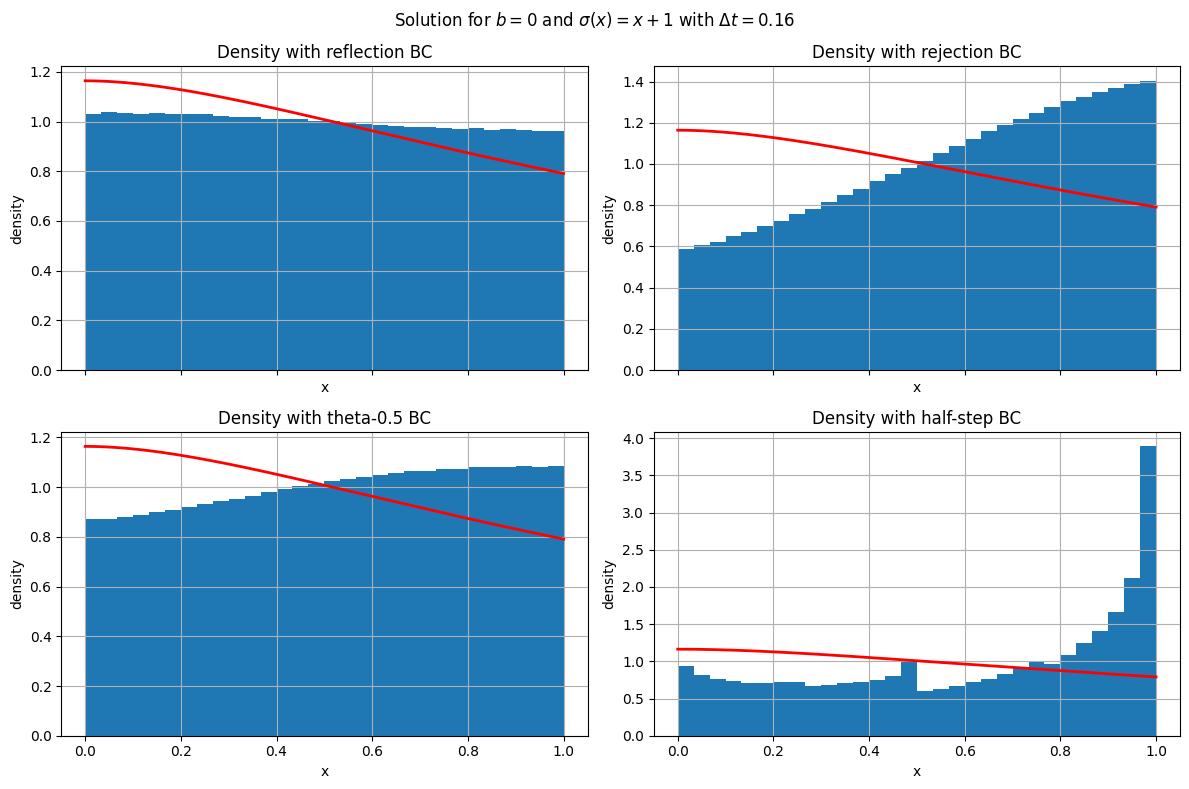

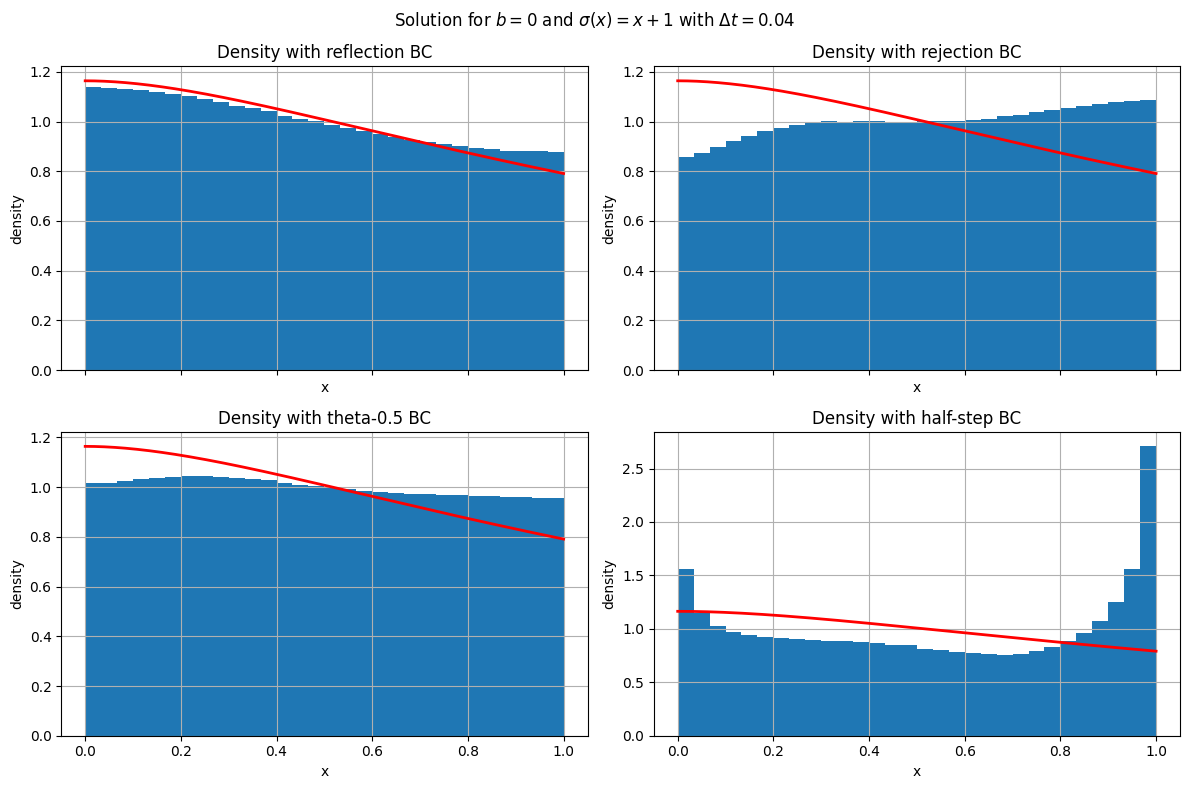

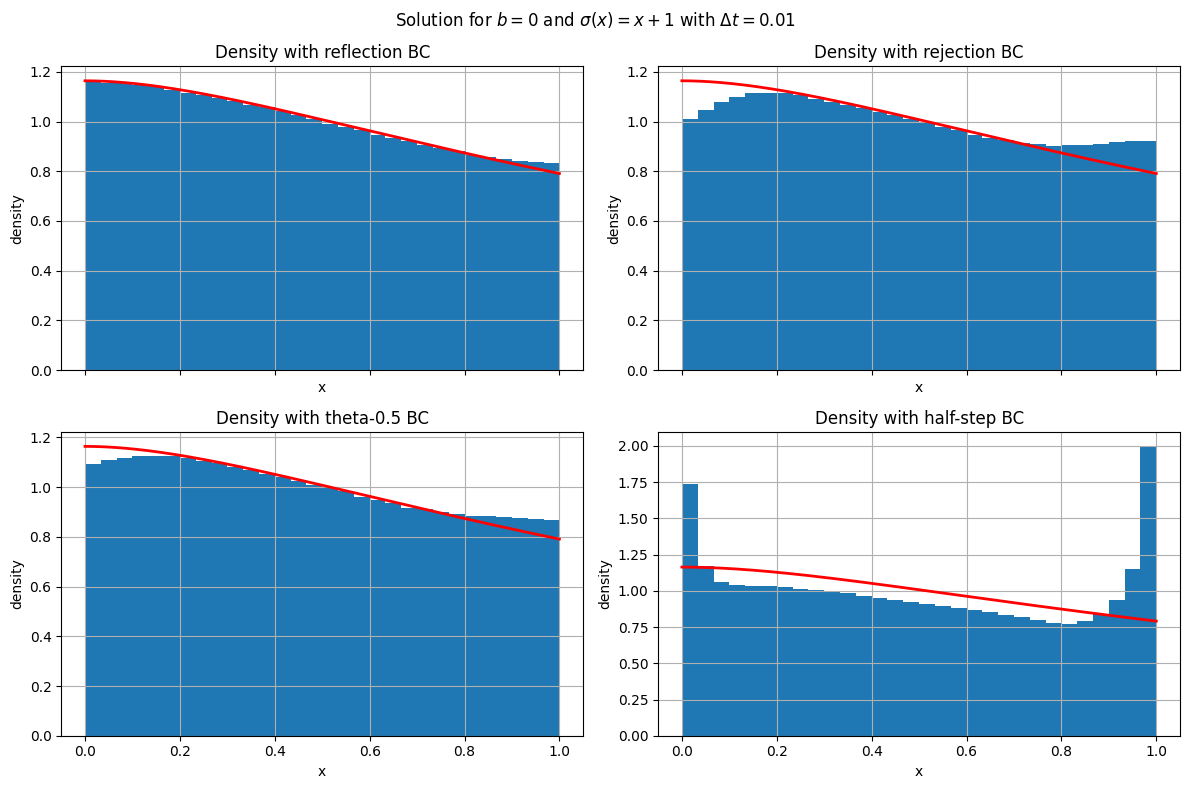

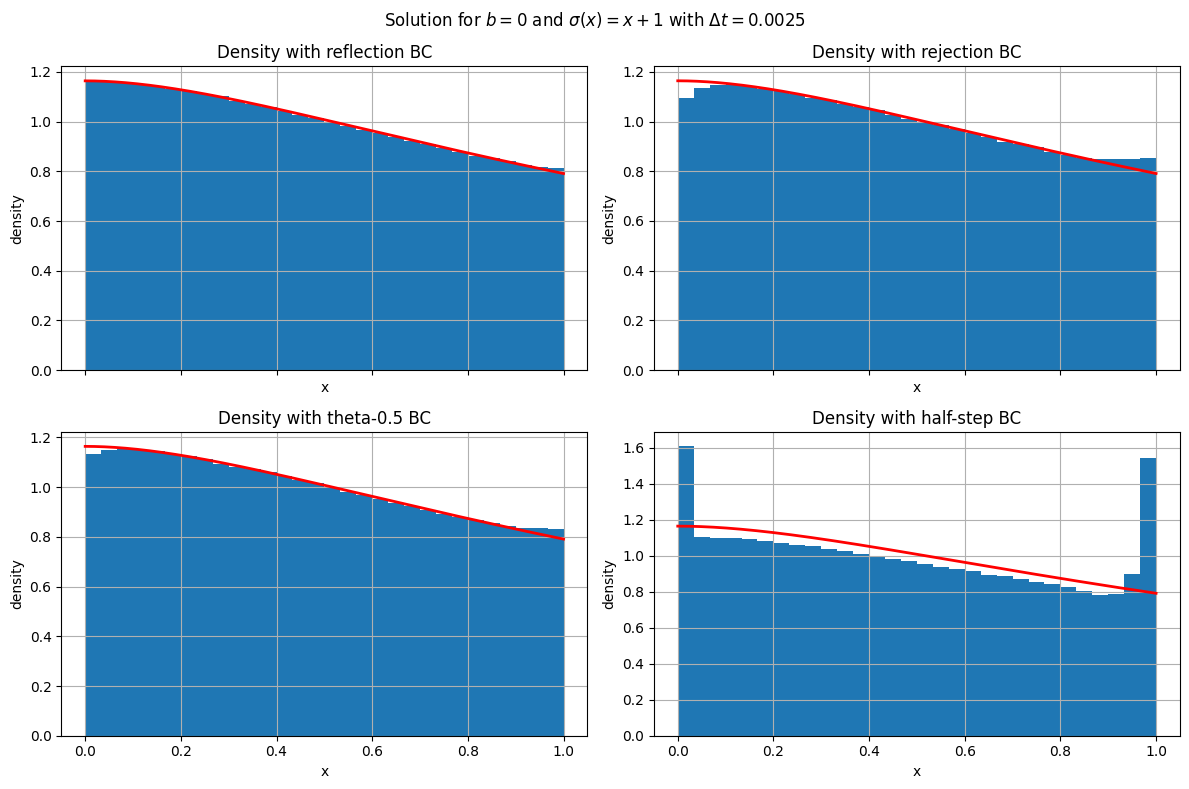

In [4]:

#compute the stationary solution
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)


for dt in dt_list:

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
    ax = ax.flatten()

    fig.suptitle(fr"Solution for $b=0$ and $\sigma(x)=x+1$ with $\Delta t={dt}$")

    for i, boundary_type in enumerate(boundary_types):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        plot_histogram(X=X, bins=30, ax=ax[i], title=f'Density with {boundary_type} BC'
                       ,x_label='x', y_label='density', density=True, x_limit=None)
        ax[i].plot(x_plot, p_exact, "r", linewidth=2)

    plt.tight_layout()
    plt.show()


## Solutions in the range $[0,\varepsilon]$

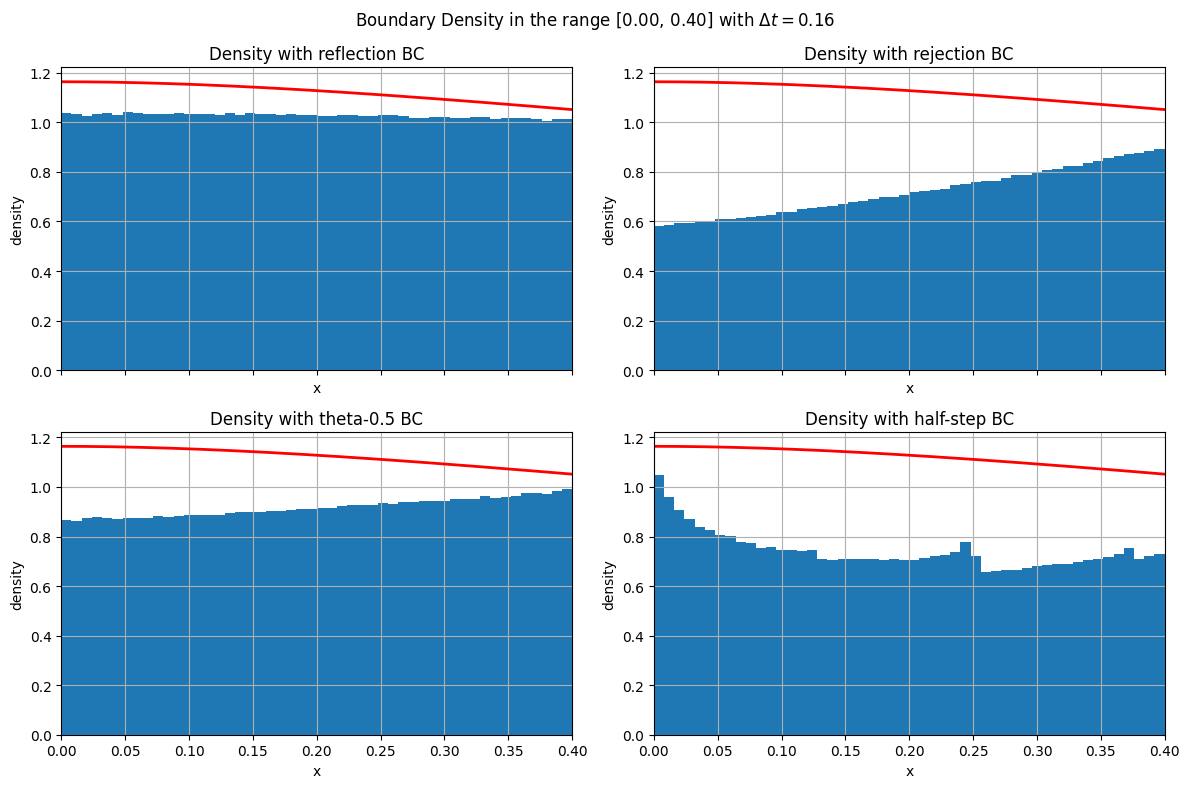

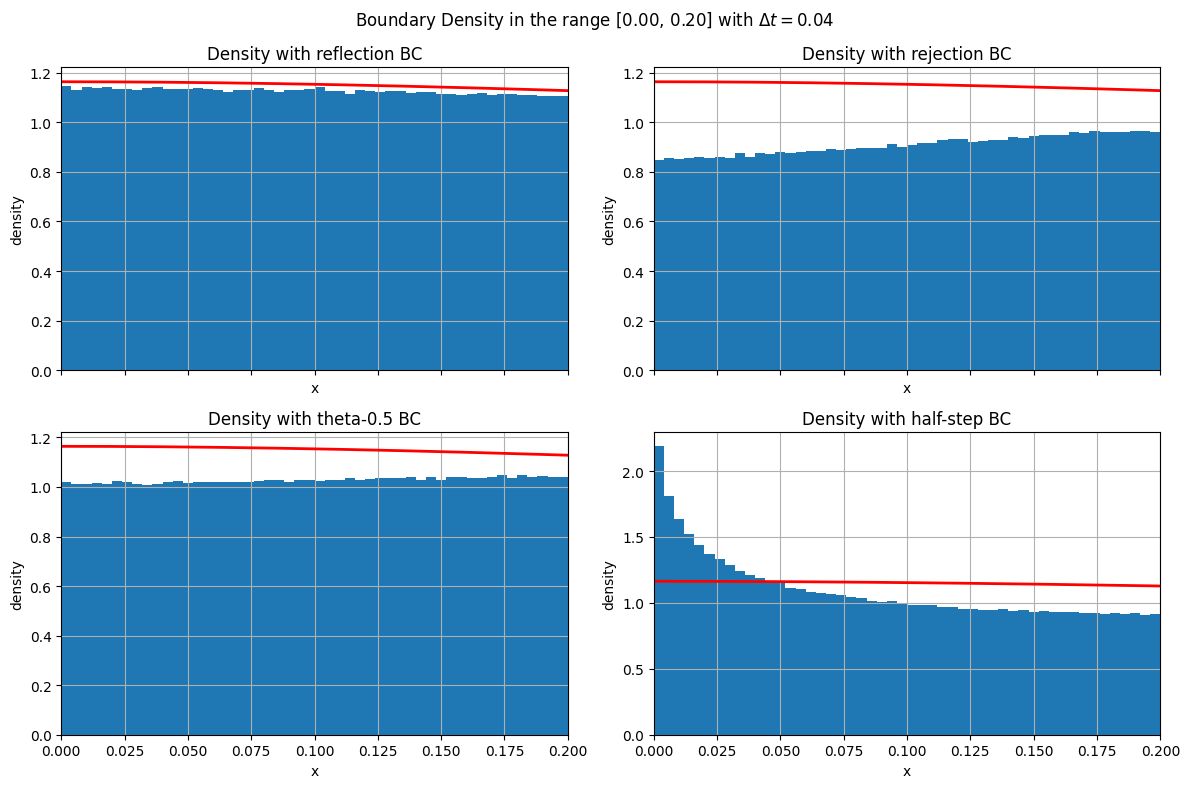

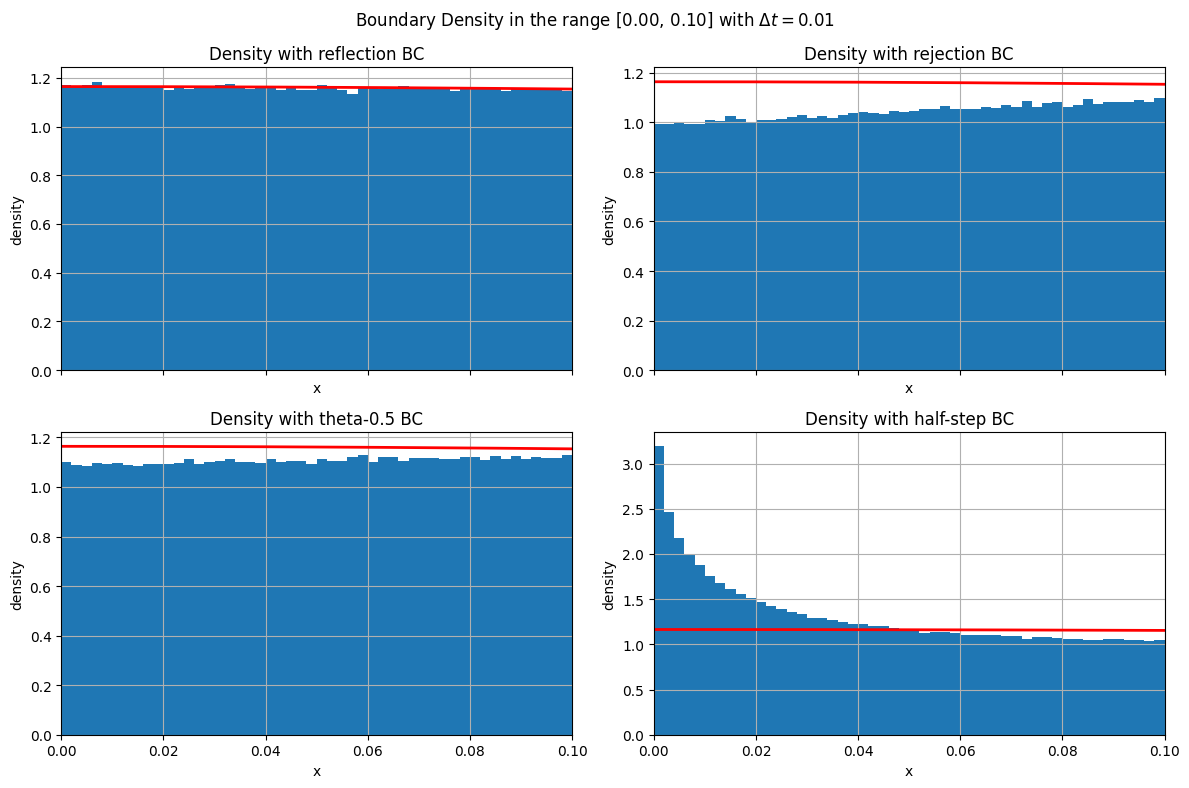

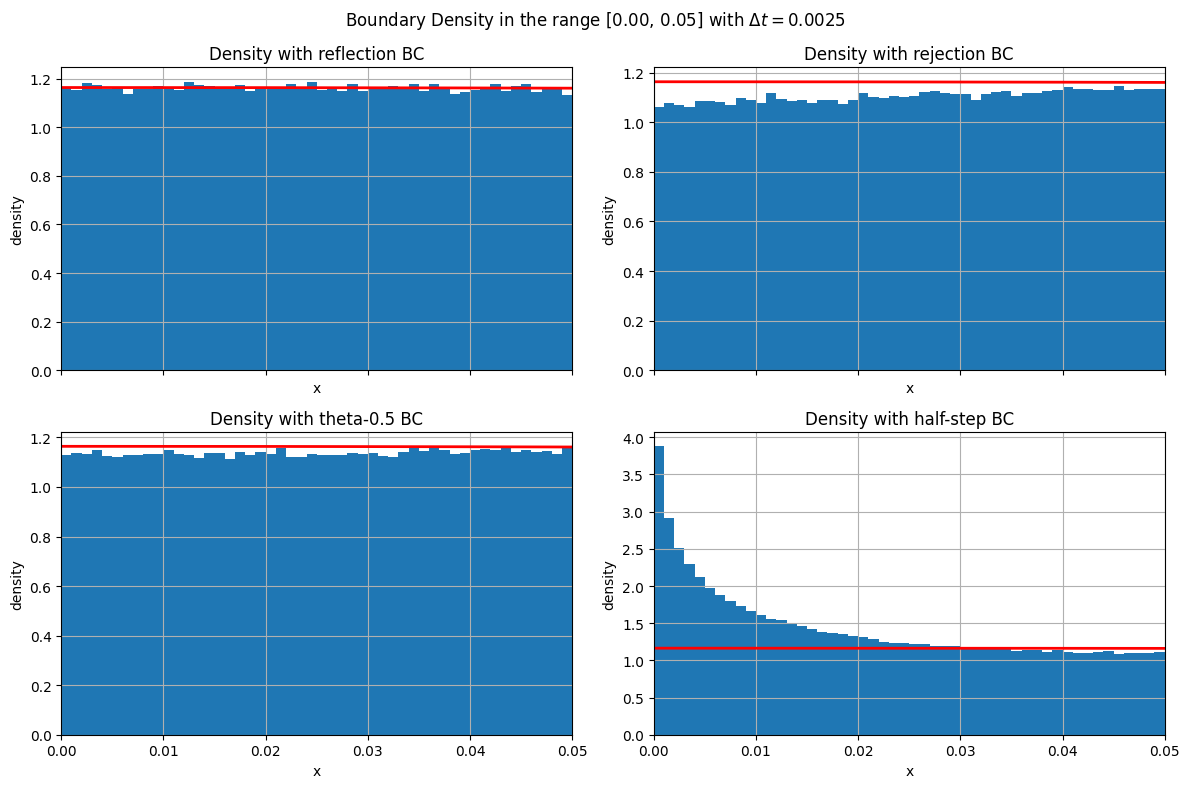

In [5]:

bins=50

for dt in dt_list:

    epsilon = np.sqrt(dt)
    x_range = (x_bounds[0], x_bounds[0] + epsilon)

    x_plot = np.linspace(x_range[0], x_range[1], 500)
    p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
    ax = ax.flatten()

    fig.suptitle(fr"Boundary Density in the range [{x_range[0]:.2f}, {x_range[1]:.2f}] with $\Delta t={dt}$")

    for i, boundary_type in enumerate(boundary_types):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        plot_local_density(X=X, x_range=x_range, bins=bins, ax=ax[i]
                           , title=f'Density with {boundary_type} BC')
        ax[i].plot(x_plot, p_exact , "r", linewidth=2)

    plt.tight_layout()
    plt.show()



## Solutions in the range $[1-\varepsilon, 1]$

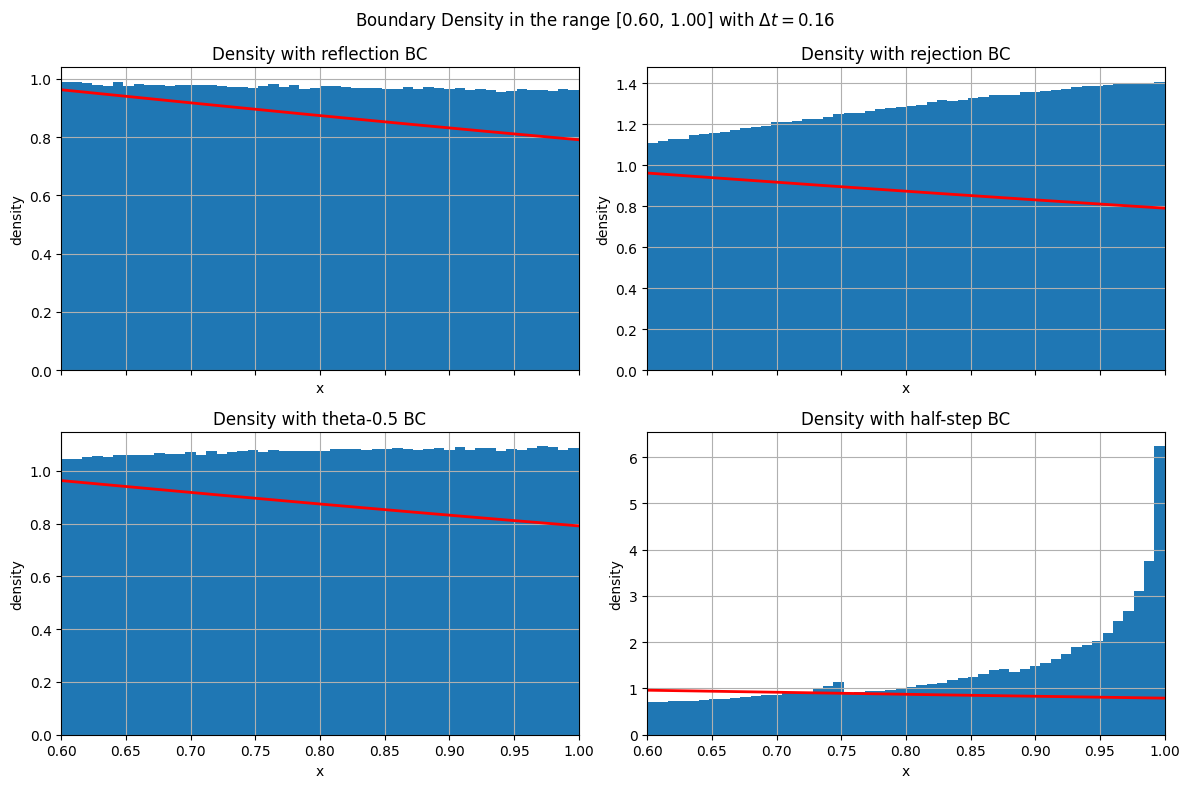

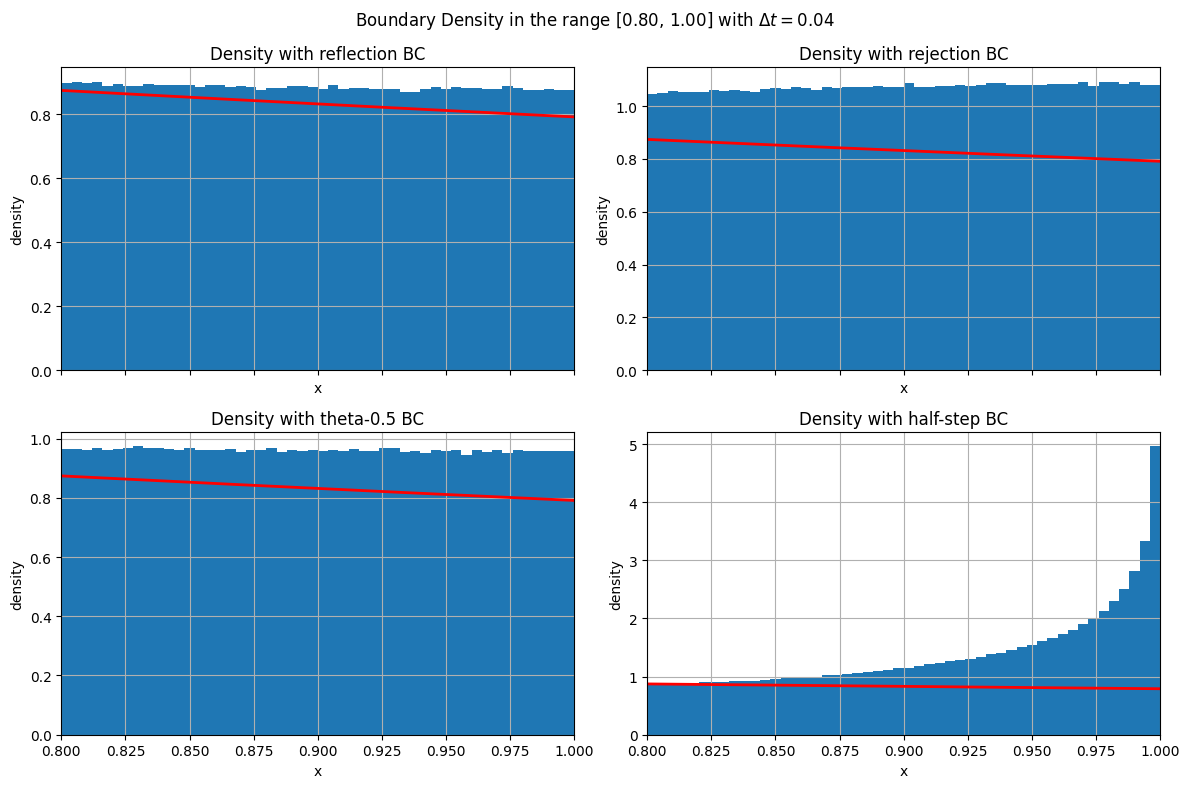

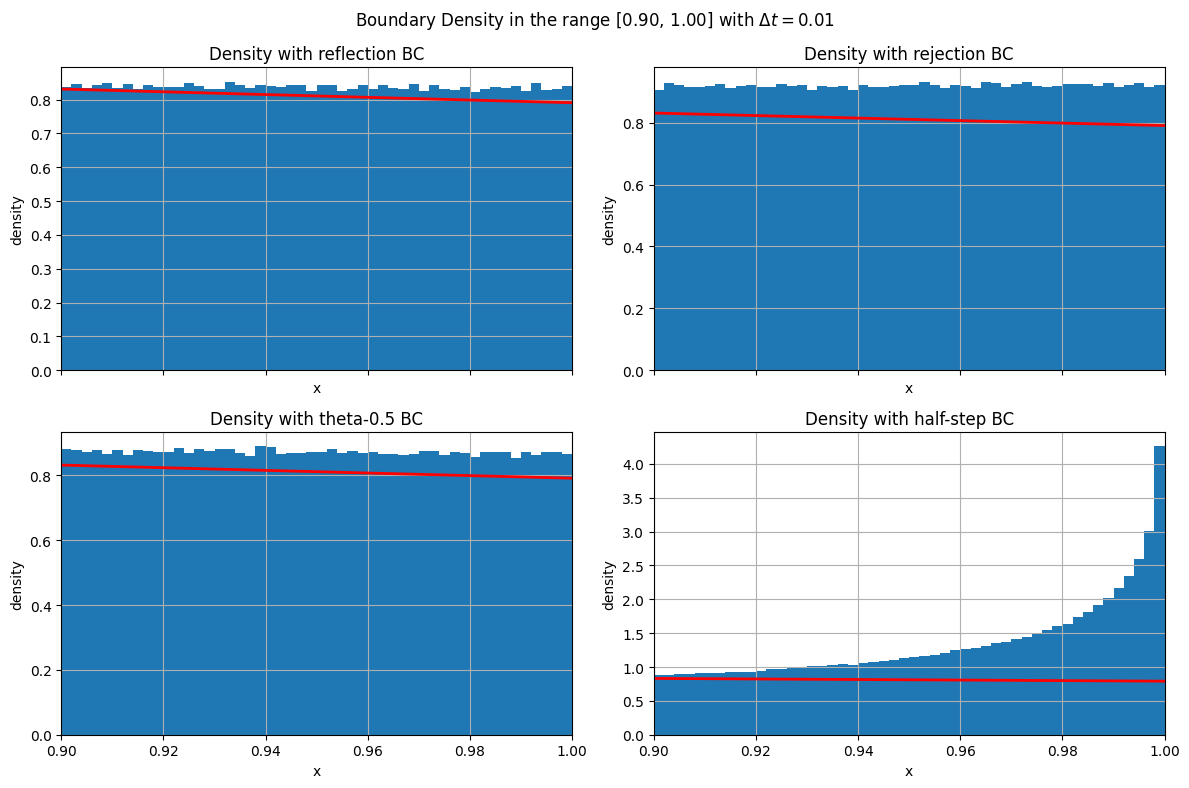

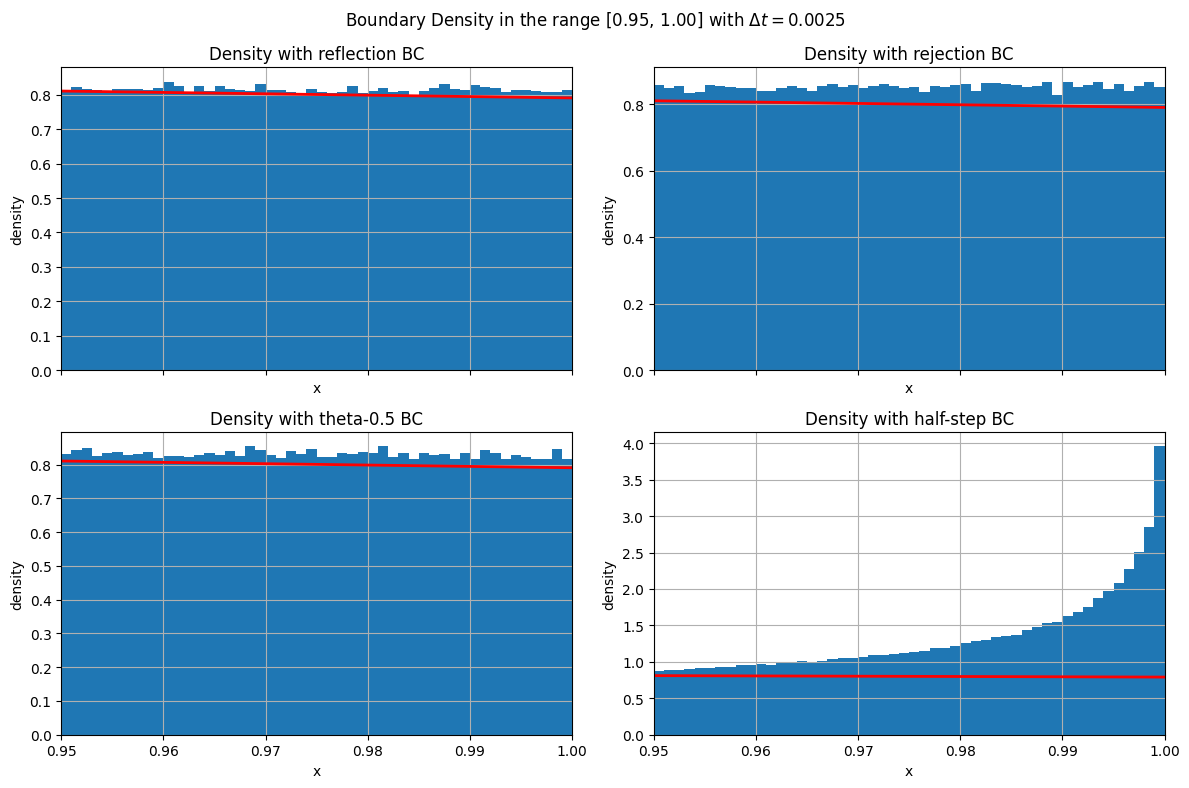

In [6]:

bins=50

for dt in dt_list:

    epsilon = np.sqrt(dt)
    x_range = (x_bounds[1] - epsilon, x_bounds[1])

    x_plot = np.linspace(x_range[0], x_range[1], 500)
    p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
    ax = ax.flatten()

    fig.suptitle(fr"Boundary Density in the range [{x_range[0]:.2f}, {x_range[1]:.2f}] with $\Delta t={dt}$")

    for i, boundary_type in enumerate(boundary_types):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        plot_local_density(X=X, x_range=x_range, bins=bins, ax=ax[i]
                           , title=f'Density with {boundary_type} BC')
        ax[i].plot(x_plot, p_exact , "r", linewidth=2)

    plt.tight_layout()
    plt.show()



## Local error in the full domain

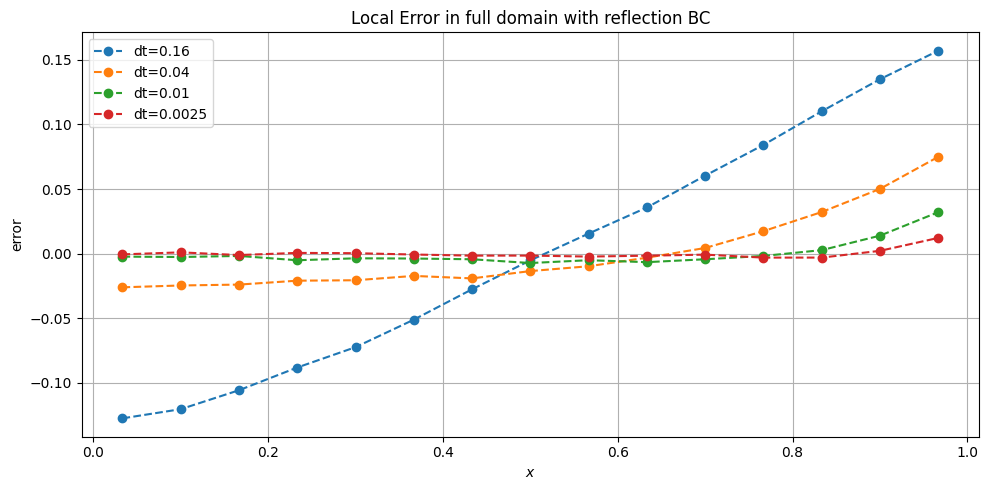

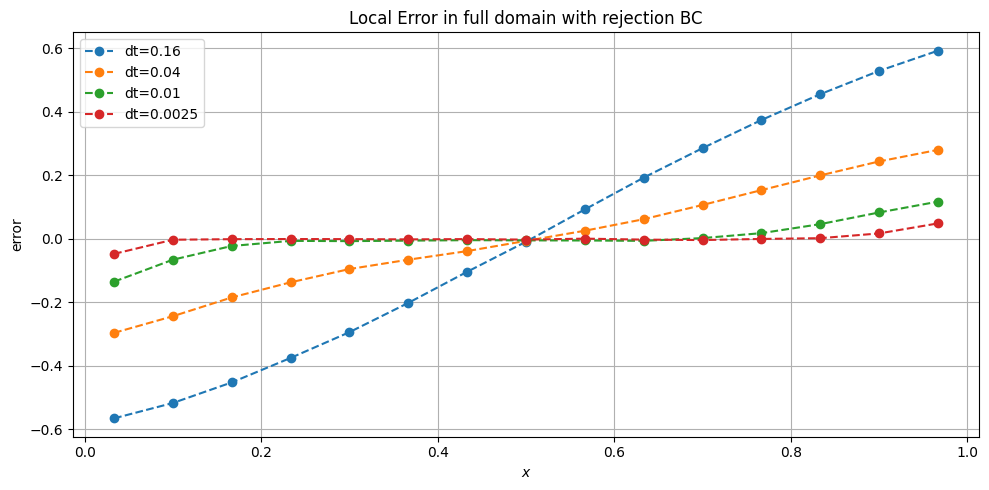

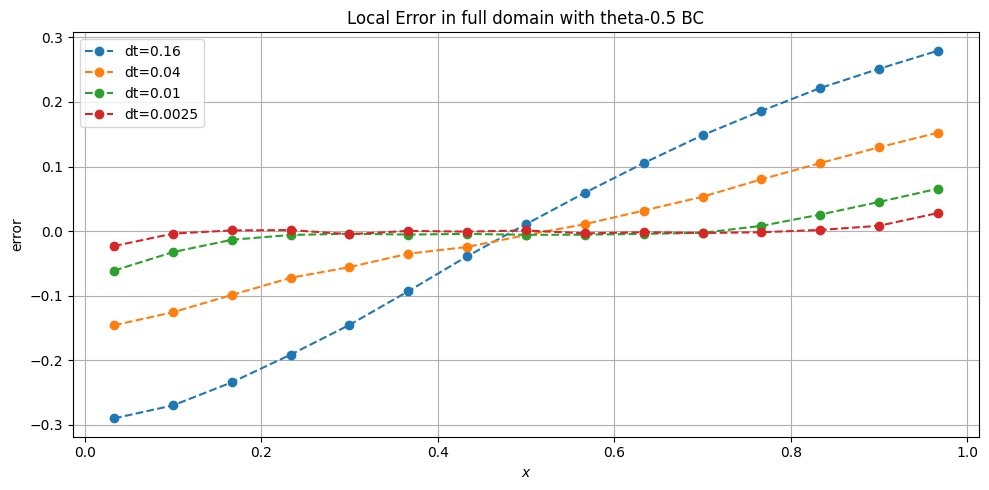

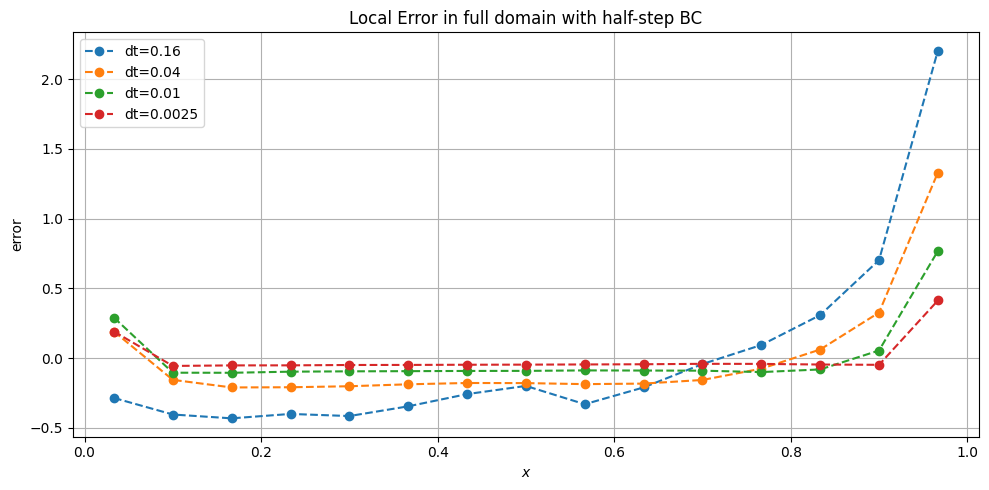

,boundary_type,dt,L1_error,L2_error,relative_error
0,reflection,0.1600,0.079826,0.091608,0.090978
1,reflection,0.0400,0.023919,0.029652,0.029448
2,reflection,0.0100,0.006547,0.009889,0.009821
3,reflection,0.0025,0.002192,0.003546,0.003522
4,rejection,0.1600,0.336170,0.380984,0.378366
5,rejection,0.0400,0.142620,0.169757,0.168591
6,rejection,0.0100,0.035419,0.055573,0.055191
7,rejection,0.0025,0.009007,0.018147,0.018023
8,theta-0.5,0.1600,0.168408,0.190072,0.188766
9,theta-0.5,0.0400,0.075211,0.088965,0.088353


In [7]:


bins=15

error_rows = []


for boundary_type in boundary_types:

    plt.figure(figsize=(10, 5))

    plt.title(f"Local Error in full domain with {boundary_type} BC")
    
    for i, dt in enumerate(dt_list):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        p_num, centres, counts, edges, bin_widths = histogram_density(X, x_bounds, bins)
        p_exact = stationary_solution(centres, b, sigma, x_bounds)
    
        local_error, L1_error, L2_error, relative_error = density_errors(p_num, p_exact, bin_widths)
        
        plt.plot(centres, local_error, marker="o", linestyle="--", label=f"dt={dt}")
    
        error_rows.append({"boundary_type": boundary_type, "dt": dt, "L1_error": L1_error,
            "L2_error": L2_error, "relative_error": relative_error})

    plt.xlabel(r"$x$")
    plt.ylabel("error")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

error_table = pd.DataFrame(error_rows)
display(error_table)



## Convergence with diffrent BC

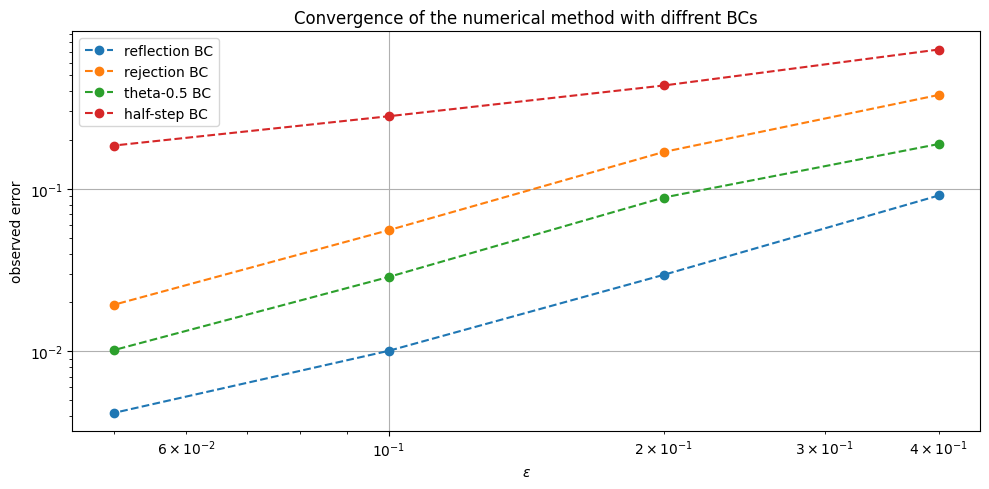

,boundary_type,observed_order
0,reflection,1.489661
1,rejection,1.447603
2,theta-0.5,1.427274
3,half-step,0.652145


In [8]:

bins=50

epsilon_list = [np.sqrt(dt) for dt in dt_list]

order_rows = []

plt.figure(figsize=(10, 5))
plt.title(f"Convergence of the numerical method with diffrent BCs")

for boundary_type in boundary_types:

    errors = []

    for i, dt in enumerate(dt_list):

        #load the precomputed solution
        X = load_solution((f"{boundary_type}_dt-{dt}.npy"), problem_path)

        p_num, centres, counts, edges, bin_widths = histogram_density(X, x_bounds, bins)
        p_exact = stationary_solution(centres, b, sigma, x_bounds)
    
        local_error, L1_error, L2_error, relative_error = density_errors(p_num, p_exact, bin_widths)
        
        errors.append(relative_error)

    epsilon_list = np.array(epsilon_list)
    errors = np.array(errors)

    plt.loglog(epsilon_list, errors, marker="o", linestyle="--", label=f"{boundary_type} BC")

    order = np.polyfit(np.log(epsilon_list), np.log(errors), 1)[0]

    order_rows.append({"boundary_type":boundary_type, "observed_order": order})
    
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"observed error")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


convergence_table = pd.DataFrame(order_rows)
display(convergence_table)




## Local error in the scaled boundary close to $x=0$

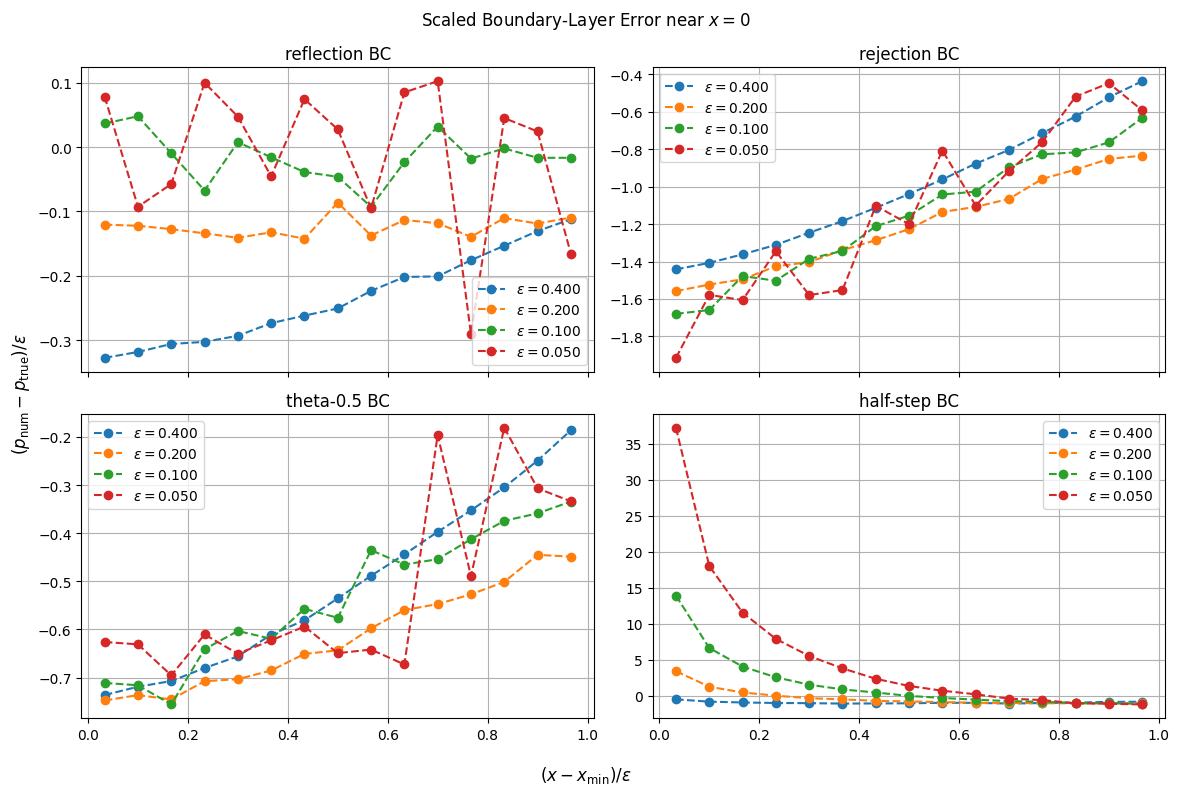

In [9]:
bins = 15

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
ax = ax.flatten()

fig.suptitle(fr"Scaled Boundary-Layer Error near $x=0$")

for i, boundary_type in enumerate(boundary_types):

    for dt in dt_list:

        epsilon = np.sqrt(dt)
        x_range = (x_bounds[0], x_bounds[0]+ epsilon)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, centres, counts, edges, bin_widths = histogram_density(X, x_range, bins)
        p_exact = stationary_solution(centres, b, sigma, x_bounds)

        x_scaled = (centres - x_bounds[0]) / epsilon
        error_scaled = (p_num - p_exact) / epsilon

        ax[i].plot(x_scaled, error_scaled, marker="o", linestyle="--",
                   label=fr"$\varepsilon={epsilon:.3f}$")

    ax[i].set_title(f"{boundary_type} BC")
    ax[i].grid(True)
    ax[i].legend()

fig.supxlabel(r"$(x - x_{\min})/\varepsilon$")
fig.supylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\varepsilon$")

plt.tight_layout()
plt.show()

## Local error in the scaled boundary close to $x=1$

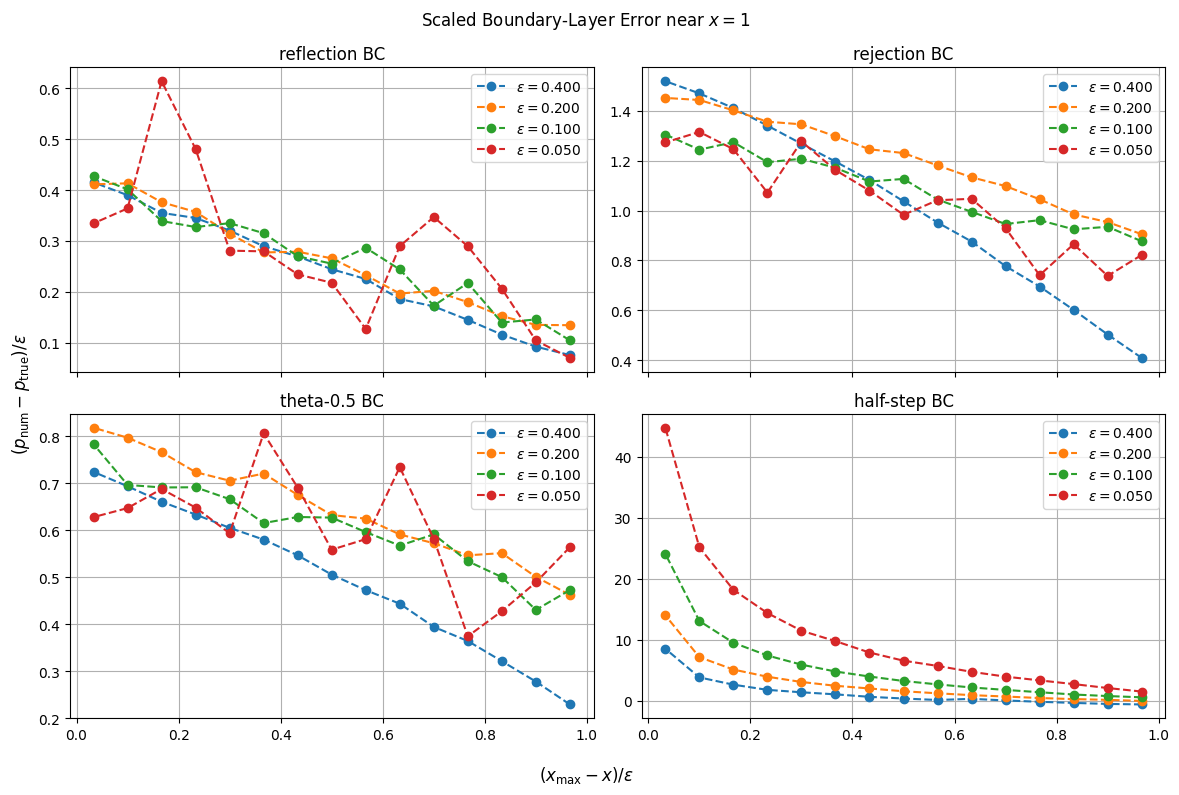

In [10]:
bins = 15

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
ax = ax.flatten()

fig.suptitle(fr"Scaled Boundary-Layer Error near $x=1$")

for i, boundary_type in enumerate(boundary_types):

    for dt in dt_list:

        epsilon = np.sqrt(dt)
        x_range = (x_bounds[1] - epsilon, x_bounds[1])

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, centres, counts, edges, bin_widths = histogram_density(X, x_range, bins)
        p_exact = stationary_solution(centres, b, sigma, x_bounds)

        x_scaled = (x_bounds[1] - centres) / epsilon
        error_scaled = (p_num - p_exact) / epsilon

        ax[i].plot(x_scaled, error_scaled, marker="o", linestyle="--",
                   label=fr"$\varepsilon={epsilon:.3f}$")

    ax[i].set_title(f"{boundary_type} BC")
    ax[i].grid(True)
    ax[i].legend()

fig.supxlabel(r"$(x_{\max} - x)/\varepsilon$")
fig.supylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\varepsilon$")

plt.tight_layout()
plt.show()

## Gap in boundary layer

In [11]:
def boundary_gap(X, b, sigma, boundaries, x_range, bins=30):

    p_num, centres, counts, edges, bin_widths = histogram_density(X, x_range, bins)
    p_exact = stationary_solution(centres, b, sigma, boundaries)

    if x_range[0] == boundaries[0]:
        index = 0
    elif x_range[1] == boundaries[1]:
        index = -1

    gap = np.abs(p_num[index] - p_exact[index])

    return gap

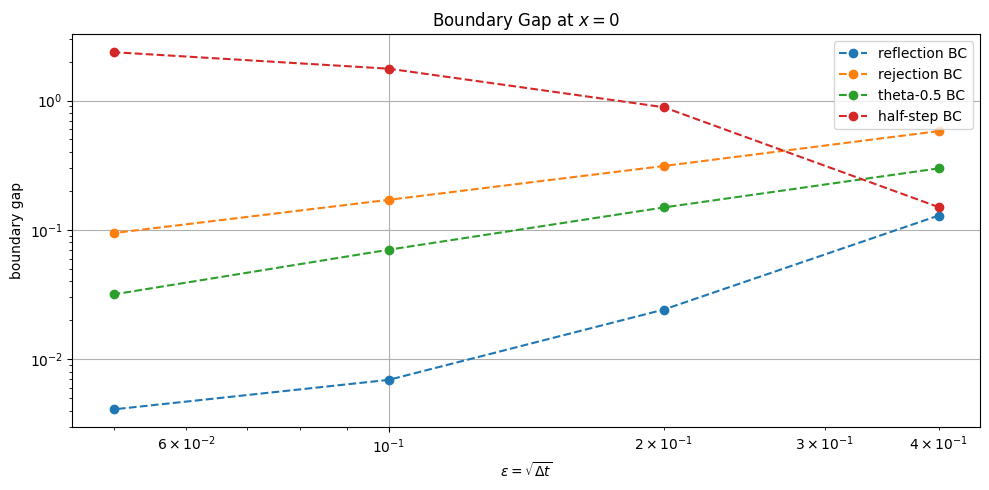

,x=,boundary_type,dt,epsilon,gap,gap_over_epsilon
0,0,reflection,0.1600,0.40,0.129105,0.322762
1,0,reflection,0.0400,0.20,0.024181,0.120903
2,0,reflection,0.0100,0.10,0.006920,0.069198
3,0,reflection,0.0025,0.05,0.004093,0.081852
4,0,rejection,0.1600,0.40,0.580252,1.450630
5,0,rejection,0.0400,0.20,0.311671,1.558353
6,0,rejection,0.0100,0.10,0.170770,1.707702
7,0,rejection,0.0025,0.05,0.094453,1.889052
8,0,theta-0.5,0.1600,0.40,0.298972,0.747430
9,0,theta-0.5,0.0400,0.20,0.148966,0.744828


In [12]:
bins = 30

gap_rows = []

plt.figure(figsize=(10, 5))

for boundary_type in boundary_types:

    gaps = []

    for dt in dt_list:

        epsilon = np.sqrt(dt)

        x_range = (x_bounds[0], x_bounds[0]+ epsilon)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        gap = boundary_gap(X, b, sigma, x_bounds, x_range, bins=bins)
        gaps.append(gap)

        gap_rows.append({
            "x=": 0,
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": epsilon,
            "gap": gap,
            "gap_over_epsilon": gap / epsilon
        })

    plt.loglog(np.sqrt(dt_list), gaps, marker="o", linestyle="--", label=f"{boundary_type} BC")

plt.xlabel(r"$\varepsilon=\sqrt{\Delta t}$")
plt.ylabel("boundary gap")
plt.title(fr"Boundary Gap at $x={x_bounds[0]}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

gap_table = pd.DataFrame(gap_rows)
display(gap_table)

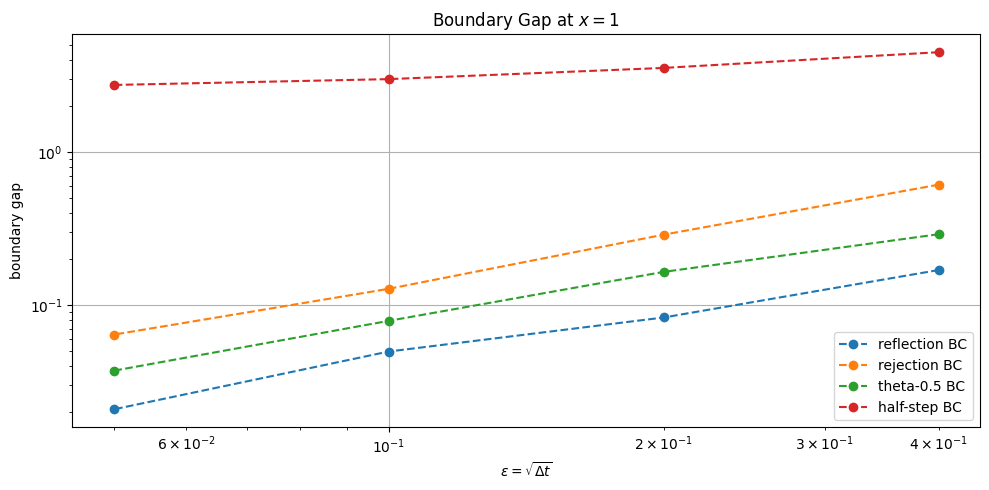

,x=,boundary_type,dt,epsilon,gap,gap_over_epsilon
0,1,reflection,0.1600,0.40,0.169288,0.423220
1,1,reflection,0.0400,0.20,0.082777,0.413886
2,1,reflection,0.0100,0.10,0.049552,0.495522
3,1,reflection,0.0025,0.05,0.020722,0.414440
4,1,rejection,0.1600,0.40,0.613011,1.532527
5,1,rejection,0.0400,0.20,0.288502,1.442511
6,1,rejection,0.0100,0.10,0.127522,1.275222
7,1,rejection,0.0025,0.05,0.063922,1.278440
8,1,theta-0.5,0.1600,0.40,0.290503,0.726258
9,1,theta-0.5,0.0400,0.20,0.164632,0.823161


In [13]:
bins = 30

gap_rows = []

plt.figure(figsize=(10, 5))

for boundary_type in boundary_types:

    gaps = []

    for dt in dt_list:

        epsilon = np.sqrt(dt)

        x_range = (x_bounds[1] - epsilon, x_bounds[1])

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        gap = boundary_gap(X, b, sigma, x_bounds, x_range, bins=bins)
        gaps.append(gap)

        gap_rows.append({
            "x=": 1,
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": epsilon,
            "gap": gap,
            "gap_over_epsilon": gap / epsilon
        })

    plt.loglog(np.sqrt(dt_list), gaps, marker="o", linestyle="--", label=f"{boundary_type} BC")

plt.xlabel(r"$\varepsilon=\sqrt{\Delta t}$")
plt.ylabel("boundary gap")
plt.title(fr"Boundary Gap at $x={x_bounds[1]}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

gap_table = pd.DataFrame(gap_rows)
display(gap_table)